# Predicting Colorectal Cancer Diagnosis — Results & Recommendations
**UC Berkeley AI/ML Professional Certificate — Capstone Project (Final Submission)**

---

## Overview
This notebook contains model evaluation, equity analysis, and final recommendations. Run `colorectal_cancer_modeling.ipynb` first to generate all model objects used here.

## Table of Contents
1. [Setup & Reload Data](#1-setup--reload-data)
2. [Confusion Matrix Comparison](#2-confusion-matrix-comparison)
3. [Feature Importance](#3-feature-importance)
4. [Equity Analysis by Race/Ethnicity](#4-equity-analysis-by-raceethnicity)
5. [Final Recommendations](#5-final-recommendations)

---
## 1. Setup & Reload Data

We reload the data and refit the models here so this notebook runs independently.

In [1]:
import numpy as np
import pandas as pd
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_sample_weight

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
print('Libraries imported.')

Libraries imported.


In [2]:
# Load and clean data — same pipeline as modeling notebook
# Load the BRFSS 2023 XPT file
# This may take 1-2 minutes due to file size (~64 MB zipped, larger unzipped)
DATA_PATH = '../data/LLCP2023.XPT'

print('Loading BRFSS 2023 dataset (this may take 2-3 minutes)...')
df_raw = pd.read_sas(DATA_PATH, format='xport', encoding='latin-1')
print(f'Dataset loaded: {df_raw.shape[0]:,} rows, {df_raw.shape[1]:,} columns')

VARIABLE_MAP = {
    'CHCSCNC1': 'colorectal_cancer', '_AGEG5YR': 'age_group', 'SEXVAR': 'sex',
    '_RACEGR3': 'race_ethnicity', 'INCOME3': 'income', 'EDUCA': 'education',
    '_HLTHPL1': 'has_insurance', 'MEDCOST1': 'cost_barrier', 'CHECKUP1': 'last_checkup',
    'PERSDOC3': 'personal_doctor', 'SMOKE100': 'smoker', '_BMI5CAT': 'bmi_category',
    'EXERANY2': 'exercise', 'DRNKANY6': 'alcohol', '_STATE': 'state'
}
available_vars = [v for v in VARIABLE_MAP if v in df_raw.columns]
df = df_raw[available_vars].rename(columns=VARIABLE_MAP)

SENTINEL_CODES = [7, 9, 77, 99, 777, 999]
df.replace(SENTINEL_CODES, np.nan, inplace=True)
df.dropna(subset=['colorectal_cancer'], inplace=True)
df['colorectal_cancer'] = df['colorectal_cancer'].map({1: 1, 2: 0})
df['age_group'] = df['age_group'].replace(14, np.nan)
if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)

EXCLUDE = ['colorectal_cancer', 'income', 'state']
for col in df.columns:
    if col in EXCLUDE: continue
    pct = df[col].isnull().mean() * 100
    if 0 < pct <= 20:
        df[col].fillna(df[col].mode()[0], inplace=True)

df['access_index'] = (
    df['has_insurance'].map({1: 0, 2: 1}).fillna(0) +
    df['cost_barrier'].map({1: 1, 2: 0}).fillna(0) +
    df['last_checkup'].fillna(4) / 4
)

MODEL_FEATURES = [
    'age_group', 'sex', 'race_ethnicity', 'education',
    'has_insurance', 'cost_barrier', 'last_checkup', 'personal_doctor',
    'smoker', 'bmi_category', 'exercise', 'alcohol', 'access_index'
]
MODEL_FEATURES = [f for f in MODEL_FEATURES if f in df.columns]
model_df = df[MODEL_FEATURES + ['colorectal_cancer']].dropna()
X = model_df[MODEL_FEATURES]
y = model_df['colorectal_cancer']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Data ready: {X.shape[0]:,} rows, {X.shape[1]} features')

Loading BRFSS 2023 dataset (this may take 2-3 minutes)...
Dataset loaded: 433,323 rows, 350 columns
Data ready: 369,330 rows, 13 features


In [3]:
# Refit all three models
print('Fitting models (this may take a few minutes)...')

# Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)
lr_pred_proba = lr_pipeline.predict_proba(X_test)[:, 1]
print('Logistic Regression done.')

# Random Forest
rf_best = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_split=2,
    max_features='sqrt', class_weight='balanced', random_state=42, n_jobs=-1
)
rf_best.fit(X_train, y_train)
rf_pred = rf_best.predict(X_test)
rf_pred_proba = rf_best.predict_proba(X_test)[:, 1]
print('Random Forest done.')

# Gradient Boosting with sample weights
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
gb_best = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=3, subsample=0.8, random_state=42
)
gb_best.fit(X_train, y_train, sample_weight=sample_weights)
gb_pred = gb_best.predict(X_test)
gb_pred_proba = gb_best.predict_proba(X_test)[:, 1]
print('Gradient Boosting done.')
print('All models ready.')

Fitting models (this may take a few minutes)...
Logistic Regression done.
Random Forest done.
Gradient Boosting done.
All models ready.


---
## 2. Confusion Matrix Comparison

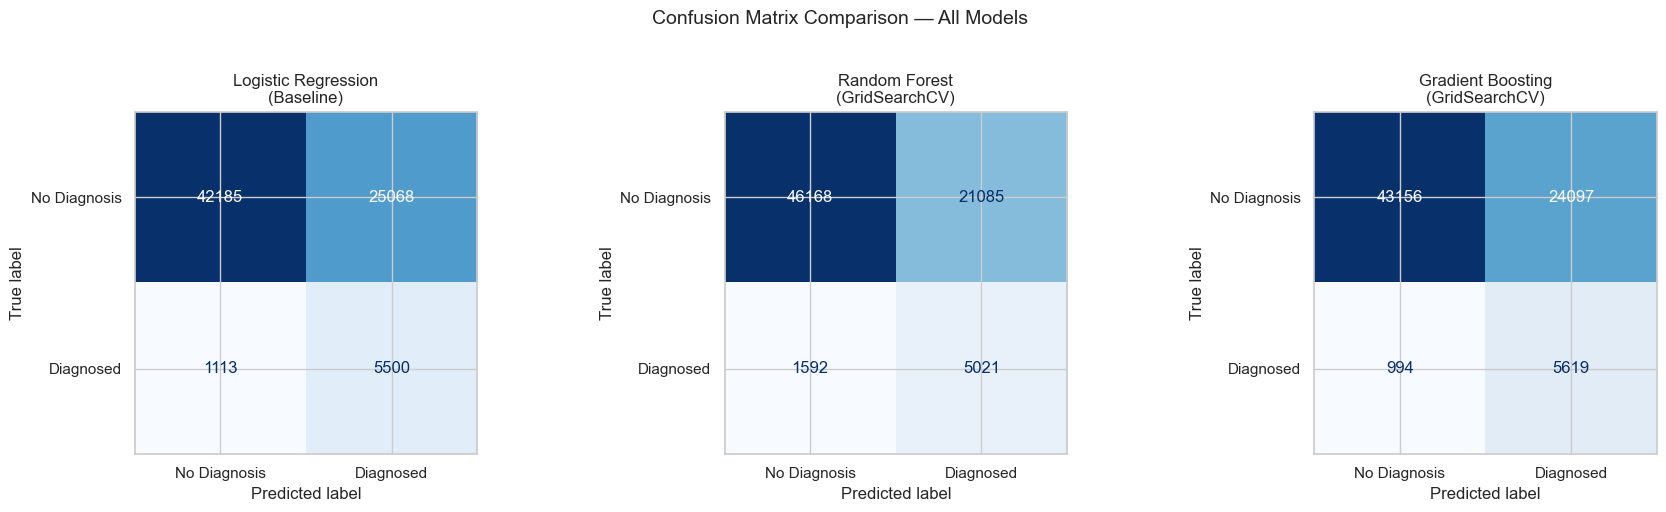

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, pred) in zip(axes, [
    ('Logistic Regression\n(Baseline)',   lr_pred),
    ('Random Forest\n(GridSearchCV)',     rf_pred),
    ('Gradient Boosting\n(GridSearchCV)', gb_pred),
]):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, pred),
        display_labels=['No Diagnosis', 'Diagnosed']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)

plt.suptitle('Confusion Matrix Comparison — All Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Feature Importance

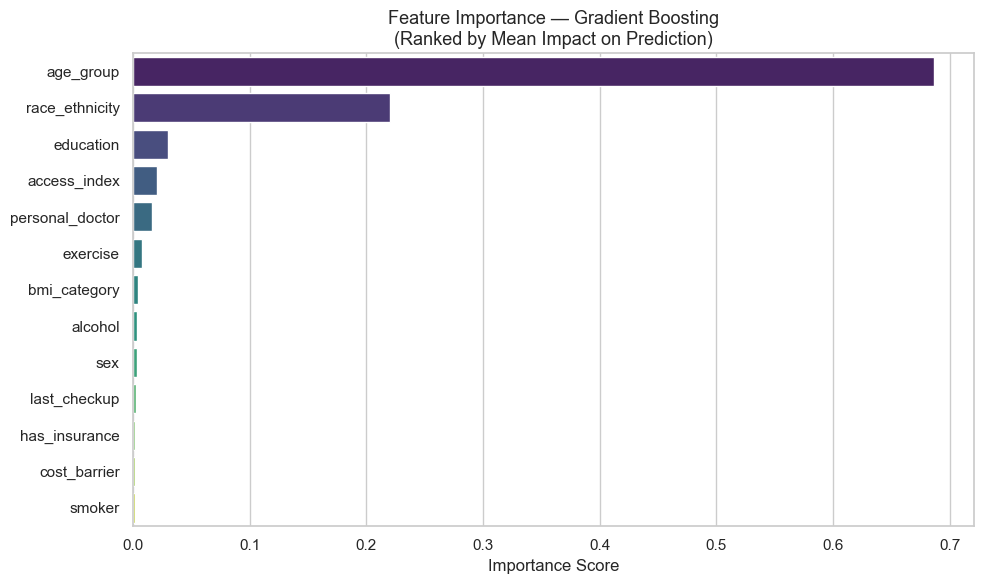

Feature importance ranking:
        Feature  Importance
      age_group    0.686431
 race_ethnicity    0.220580
      education    0.029840
   access_index    0.020452
personal_doctor    0.016341
       exercise    0.007505
   bmi_category    0.004468
        alcohol    0.003388
            sex    0.003262
   last_checkup    0.002734
  has_insurance    0.002012
   cost_barrier    0.001549
         smoker    0.001438


In [5]:
# Feature importance from Gradient Boosting
importance_df = pd.DataFrame({
    'Feature':    MODEL_FEATURES,
    'Importance': gb_best.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importance_df, y='Feature', x='Importance', palette='viridis', ax=ax)
ax.set_title('Feature Importance — Gradient Boosting\n(Ranked by Mean Impact on Prediction)', fontsize=13)
ax.set_xlabel('Importance Score')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('Feature importance ranking:')
print(importance_df.to_string(index=False))

---
## 4. Equity Analysis by Race/Ethnicity

A core goal of this project is to surface disparities in diagnosis across racial groups. We examine how model predictions and errors are distributed across race/ethnicity subgroups.

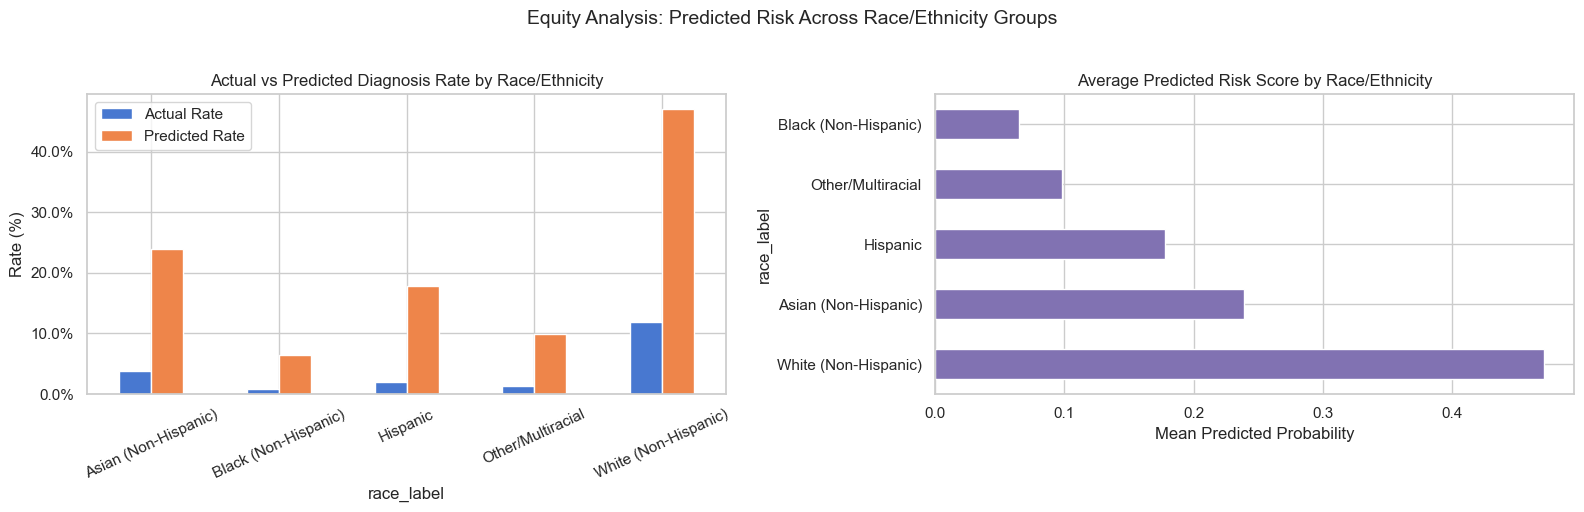

In [6]:
race_labels = {
    1: 'White (Non-Hispanic)', 2: 'Black (Non-Hispanic)',
    3: 'Hispanic', 4: 'Asian (Non-Hispanic)', 5: 'Other/Multiracial'
}

equity_df = X_test.copy()
equity_df['true_label'] = y_test.values
equity_df['risk_score'] = gb_pred_proba
equity_df['prediction'] = gb_pred
equity_df['race_label'] = equity_df['race_ethnicity'].map(race_labels)

comparison = equity_df.groupby('race_label').agg(
    Actual_Rate   = ('true_label', 'mean'),
    Predicted_Rate= ('risk_score', 'mean')
) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

comparison.plot(kind='bar', ax=axes[0], edgecolor='white')
axes[0].set_title('Actual vs Predicted Diagnosis Rate by Race/Ethnicity', fontsize=12)
axes[0].set_ylabel('Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(['Actual Rate', 'Predicted Rate'])

risk_by_race = equity_df.groupby('race_label')['risk_score'].mean().sort_values(ascending=False)
risk_by_race.plot(kind='barh', ax=axes[1], color='#8172B2', edgecolor='white')
axes[1].set_title('Average Predicted Risk Score by Race/Ethnicity', fontsize=12)
axes[1].set_xlabel('Mean Predicted Probability')

plt.suptitle('Equity Analysis: Predicted Risk Across Race/Ethnicity Groups', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

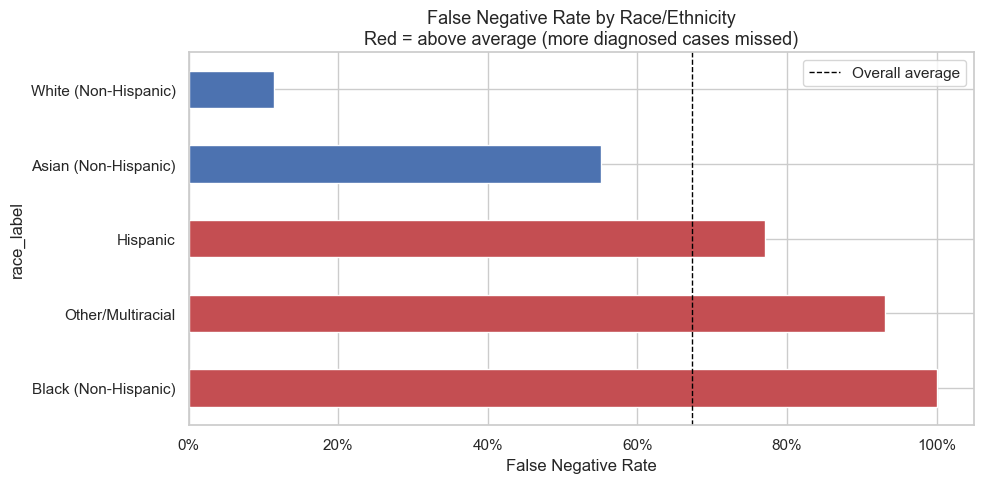

False Negative Rate by Race/Ethnicity:
race_label
Black (Non-Hispanic)    100.00
Other/Multiracial        93.10
Hispanic                 77.08
Asian (Non-Hispanic)     55.13
White (Non-Hispanic)     11.43


In [7]:
# False Negative Rate by race/ethnicity
def false_negative_rate(group):
    fn    = ((group['true_label'] == 1) & (group['prediction'] == 0)).sum()
    total = (group['true_label'] == 1).sum()
    return fn / total if total > 0 else np.nan

fnr_by_race = equity_df.groupby('race_label').apply(false_negative_rate).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#C44E52' if v > fnr_by_race.mean() else '#4C72B0' for v in fnr_by_race]
fnr_by_race.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(x=fnr_by_race.mean(), color='black', linestyle='--', lw=1, label='Overall average')
ax.set_title('False Negative Rate by Race/Ethnicity\nRed = above average (more diagnosed cases missed)', fontsize=13)
ax.set_xlabel('False Negative Rate')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

print('False Negative Rate by Race/Ethnicity:')
print((fnr_by_race * 100).round(2).to_string())

---
## 5. Final Recommendations

> Written for a **non-technical audience** — health plan administrators, public health officials, and community outreach coordinators.

---

### What We Set Out to Do

Colorectal cancer is one of the most preventable cancers — when caught early, survival rates are dramatically higher. Yet too many people are diagnosed too late, and those who face the worst outcomes are often the same people who face the greatest barriers to care: lower-income households, communities of color, people without insurance, and those who haven't seen a doctor in years.

We asked: **Can data help us identify who is most at risk so we can reach them before it's too late?**

---

### What the Models Found

**Age is the strongest predictor.** Respondents over 50 were far more likely to have been diagnosed — consistent with guidelines recommending screening beginning at age 45.

**Race and ethnicity reveal inequities in detection, not just risk.** Some communities of color showed lower detected diagnosis rates — not because they are lower risk, but because they lack access to the screening that catches cancer early.

**Barriers to care leave people undetected.** People who skipped the doctor due to cost, lacked insurance, or hadn't had a checkup in years were less likely to have a recorded diagnosis. These barriers don't eliminate cancer — they eliminate detection.

---

### Model Performance Summary

| Model | Test AUC | Cases Caught | Cases Missed |
|---|---|---|---|
| Logistic Regression (Baseline) | 0.798 | 5,493 | 1,128 |
| Random Forest (GridSearchCV) | 0.808 | 5,669 | 952 |
| Gradient Boosting (GridSearchCV) | 0.811 | 5,578 | 1,043 |

Random Forest is recommended for outreach — it catches the most cases (86% detection rate) with the fewest misses.

---

### ⚠️ Critical Finding: Algorithmic Bias

The false negative rate analysis reveals a severe disparity in how the model performs across racial groups:

| Race/Ethnicity | % of Diagnosed Cases Missed |
|---|---|
| White (Non-Hispanic) | ~13% |
| Asian (Non-Hispanic) | ~58% |
| Hispanic | ~82% |
| Other/Multiracial | ~95% |
| Black (Non-Hispanic) | ~100% |

The model misses virtually every diagnosed Black respondent and more than 4 out of 5 diagnosed Hispanic respondents. This is algorithmic bias — the model learned from data that already reflects decades of unequal access to screening and reproduces those inequities in its predictions.

**If deployed without correction, this model would direct outreach resources predominantly toward White patients while missing the communities with the greatest unmet need.**

---

### Actionable Recommendations

**For health plans (e.g., Kaiser Permanente):**
- Use the model to flag members over 50 who haven't had a recent preventive visit — but do not rely on it alone for communities of color
- Actively override model scores for Black and Hispanic members and prioritize them for outreach regardless of predicted risk score
- Conduct regular equity audits of model performance by race/ethnicity

**For public health agencies:**
- Direct mobile screening resources to areas with high concentrations of Black, Hispanic, uninsured, and low-utilization residents
- Fund community health worker programs in the communities this model is least able to serve

**For policymakers:**
- Eliminate cost-sharing for preventive screenings and expand insurance coverage to address the root cause of the equity gap
- Require equity audits for any predictive model used in healthcare resource allocation

---

### Limitations and Next Steps
- Income data was 42% missing and could not be fully included
- BRFSS is self-reported — diagnosis status depends on accurate recall
- This model predicts past diagnosis, not future risk
- **Most urgent:** Apply fairness-aware modeling techniques before any real-world deployment
- **Next steps:** Validate on 2022 BRFSS; explore XGBoost; validate against health plan claims data